# 🚀 Practice Day 21

**📅 Date:** 2026-10-02  
**📁 Category:** Phase 2 · 테이블 병합(merge/join) (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice combining multiple related tables with merge() to answer questions no single table can answer alone
  (여러 개의 연관된 테이블을 merge()로 연결해서, 테이블 하나만으로는 풀 수 없는 질문에 답하는 연습)
- Find which pet species drives the most visit revenue, which owner has the most pets, and which pet visits most often
  (어떤 반려동물 종이 진료매출을 가장 많이 견인하는지, 어떤 보호자가 가장 많은 반려동물을 등록했는지, 어떤 반려동물이 가장 자주 방문하는지 파악하기)

---
# 📂 Dataset

**Dataset Name:** Astoria Vet Clinic — Owners, Pets & Visits (3 tables) / Astoria 동물병원 — 보호자·반려동물·진료기록 (3테이블)

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** Three related tables from a small veterinary clinic in New York City. `owners` (60 rows: owner_id, owner_name, city — a NYC neighborhood), `pets` (90 rows: pet_id, owner_id → links to owners, pet_name, species, age), and `visits` (220 rows: visit_id, pet_id → links to pets, visit_date, reason, cost in USD). Every pet belongs to exactly one owner, every visit belongs to exactly one pet — clean, fully-linked keys with no missing values or duplicates. The point of this file is combining tables, not cleaning them.
(뉴욕 동물병원의 연관된 3개 테이블입니다. `owners`(60행: 보호자ID·이름·도시(뉴욕 동네)), `pets`(90행: 반려동물ID·보호자ID(owners와 연결)·이름·종·나이), `visits`(220행: 진료ID·반려동물ID(pets와 연결)·진료일·진료사유·비용(USD)). 모든 반려동물은 보호자 1명에게, 모든 진료는 반려동물 1마리에게 연결되어 있고 결측치·중복 없이 깨끗합니다. 이번 파일의 핵심은 정제가 아니라 테이블을 연결하는 것입니다.)

## Dataset Preview

In [32]:
# Dataset Preview
import pandas as pd
import numpy as np
from IPython.display import display

np.random.seed(42)
rng = np.random.default_rng(42)

# --- owners ---
first_names = ['Sarah', 'James', 'Maria', 'David', 'Emily', 'Michael', 'Laura', 'Kevin', 'Anna', 'Brian',
                'Nicole', 'Daniel', 'Rachel', 'Peter', 'Grace', 'Tom', 'Julia', 'Mark', 'Susan', 'Chris']
last_names = ['Kim', 'Park', 'Lee', 'Smith', 'Johnson', 'Garcia', 'Brown', 'Davis', 'Wilson', 'Martinez',
               'Taylor', 'Clark', 'Lewis', 'Walker', 'Hall']

n_owners = 60
owner_ids = [f'O{str(i).zfill(3)}' for i in range(1, n_owners + 1)]
owner_names = []
used = set()
while len(owner_names) < n_owners:
    name = f"{rng.choice(first_names)} {rng.choice(last_names)}"
    if name not in used:
        used.add(name)
        owner_names.append(name)
surname_map = {'Kim': 'Miller', 'Park': 'Anderson', 'Lee': 'Thomas'}
owner_names = [
    f"{first} {surname_map.get(last, last)}"
    for first, last in (name.split() for name in owner_names)
]


cities = ['Midtown', 'Williamsburg', 'Astoria', 'Chelsea', 'SoHo', 'Forest Hills']
owners = pd.DataFrame({
    'owner_id': owner_ids,
    'owner_name': owner_names,
    'city': rng.choice(cities, size=n_owners)
})

# --- pets (each owner has >=1 pet; 30 extra pets distributed randomly) ---
n_pets = 90
species_list = ['Dog', 'Cat', 'Bird', 'Rabbit', 'Reptile']
species_w = [0.45, 0.35, 0.08, 0.08, 0.04]
pet_name_pool = ['Max', 'Bella', 'Charlie', 'Luna', 'Cooper', 'Milo', 'Daisy', 'Rocky', 'Sadie', 'Buddy',
                  'Coco', 'Leo', 'Molly', 'Jack', 'Lucy', 'Oliver', 'Ruby', 'Teddy', 'Zoe', 'Duke',
                  'Chloe', 'Bear', 'Penny', 'Simba', 'Nala', 'Kiwi', 'Peanut', 'Shadow', 'Ginger', 'Biscuit']

owner_pet_counts = {oid: 1 for oid in owner_ids}
for oid in rng.choice(owner_ids, size=n_pets - n_owners, replace=True):
    owner_pet_counts[oid] += 1

pet_rows = []
pet_counter = 1
for oid, cnt in owner_pet_counts.items():
    for _ in range(cnt):
        pet_rows.append({
            'pet_id': f'P{str(pet_counter).zfill(3)}',
            'owner_id': oid,
            'pet_name': rng.choice(pet_name_pool),
            'species': rng.choice(species_list, p=species_w),
            'age': int(rng.integers(1, 15))
        })
        pet_counter += 1
pets = pd.DataFrame(pet_rows)

# --- visits (some pets visit much more often than others) ---
n_visits = 220
reasons = ['Checkup', 'Vaccination', 'Illness', 'Dental', 'Surgery', 'Emergency']
reason_w = [0.28, 0.22, 0.20, 0.10, 0.06, 0.14]
# visit cost in USD (45000 KRW -> $45)
avg_cost = {'Checkup': 45, 'Vaccination': 35, 'Illness': 85, 'Dental': 120, 'Surgery': 450, 'Emergency': 280}

pet_visit_weight = rng.gamma(shape=2.0, scale=1.0, size=n_pets)
pet_visit_p = pet_visit_weight / pet_visit_weight.sum()
visit_pet_ids = rng.choice(pets['pet_id'].values, size=n_visits, replace=True, p=pet_visit_p)
visit_dates = pd.to_datetime('2024-01-01') + pd.to_timedelta(rng.integers(0, 181, size=n_visits), unit='D')

visit_rows = []
for i in range(n_visits):
    reason = rng.choice(reasons, p=reason_w)
    cost = int(round(rng.normal(avg_cost[reason], avg_cost[reason] * 0.15)))  # whole dollars
    cost = max(10, cost)
    visit_rows.append({
        'visit_id': f'V{str(i+1).zfill(4)}',
        'pet_id': visit_pet_ids[i],
        'visit_date': visit_dates[i],
        'reason': reason,
        'cost': cost
    })
visits = pd.DataFrame(visit_rows).sort_values('visit_date').reset_index(drop=True)

print("Owners:")
display(owners.head())
print("\nPets:")
display(pets.head())
print("\nVisits:")
display(visits.head())


Owners:


,owner_id,owner_name,city
0,O001,James Clark,Astoria
1,O002,Peter Brown,Astoria
2,O003,Anna Lewis,Forest Hills
3,O004,James Taylor,Williamsburg
4,O005,Emily Anderson,Williamsburg



Pets:


,pet_id,owner_id,pet_name,species,age
0,P001,O001,Ruby,Bird,3
1,P002,O002,Max,Cat,11
2,P003,O003,Duke,Cat,7
3,P004,O004,Cooper,Cat,9
4,P005,O005,Zoe,Dog,2



Visits:


,visit_id,pet_id,visit_date,reason,cost
0,V0220,P020,2024-01-01,Checkup,54
1,V0080,P009,2024-01-01,Checkup,46
2,V0086,P067,2024-01-01,Checkup,48
3,V0007,P019,2024-01-01,Illness,62
4,V0148,P046,2024-01-01,Checkup,54


## Dataset Information

In [33]:
# Dataset Information
print("Owners:", owners.shape)
owners.info()
print("\nPets:", pets.shape)
pets.info()
print("\nVisits:", visits.shape)
visits.info()

print("\n--- Describe: Owners ---")
display(owners.describe(include='all'))
print("\n--- Describe: Pets ---")
display(pets.describe(include='all'))
print("\n--- Describe: Visits ---")
display(visits.describe(include='all'))


Owners: (60, 3)
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   owner_id    60 non-null     str  
 1   owner_name  60 non-null     str  
 2   city        60 non-null     str  
dtypes: str(3)
memory usage: 1.5 KB

Pets: (90, 5)
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pet_id    90 non-null     str  
 1   owner_id  90 non-null     str  
 2   pet_name  90 non-null     str  
 3   species   90 non-null     str  
 4   age       90 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.6 KB

Visits: (220, 5)
<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   visit_id    220 non-null    str        

,owner_id,owner_name,city
count,60,60,60
unique,60,60,6
top,O001,James Clark,Astoria
freq,1,1,15



--- Describe: Pets ---


,pet_id,owner_id,pet_name,species,age
count,90,90,90,90,90.000000
unique,90,60,28,5,NaN
top,P001,O016,Sadie,Dog,NaN
freq,1,4,7,40,NaN
mean,NaN,NaN,NaN,NaN,6.766667
std,NaN,NaN,NaN,NaN,4.200187
min,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,3.000000
50%,NaN,NaN,NaN,NaN,7.000000
75%,NaN,NaN,NaN,NaN,10.750000



--- Describe: Visits ---


,visit_id,pet_id,visit_date,reason,cost
count,220,220,220,220,220.000000
unique,220,73,NaN,6,NaN
top,V0220,P047,NaN,Checkup,NaN
freq,1,8,NaN,68,NaN
mean,NaN,NaN,2024-03-24 05:20:43.636363,NaN,115.568182
min,NaN,NaN,2024-01-01 00:00:00,NaN,23.000000
25%,NaN,NaN,2024-02-08 12:00:00,NaN,41.000000
50%,NaN,NaN,2024-03-22 12:00:00,NaN,58.000000
75%,NaN,NaN,2024-05-11 06:00:00,NaN,125.500000
max,NaN,NaN,2024-06-29 00:00:00,NaN,572.000000


---
# ❓ Business Questions

1. **(Analysis)** Which pet species generates the most total visit revenue, and which the least?
   (어떤 반려동물 종이 진료매출을 가장 많이/적게 견인하는가?)
2. **(Analysis)** Which owner has registered the most pets?
   (가장 많은 반려동물을 등록한 보호자는 누구인가?)
3. **(Analysis)** Which pet has had the most visits, and who is their owner?
   (방문 횟수가 가장 많은 반려동물은 누구이며, 그 보호자는?)
4. **(Visualization)** Compare total visit revenue across all five species.
   (5개 종의 총 진료매출을 비교하면?)
5. **(Visualization)** Compare visit counts across the different visit reasons.
   (방문 사유별 건수를 비교하면?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `merge`, `groupby`, `sort_values`
  (테이블 연결, 그룹별 집계, 정렬)
- [ ] SQL
- [x] Matplotlib — `plt.subplots`
  (그림과 축)
- [x] Other: Seaborn — `sns.barplot`
  (막대 차트)


---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0 in `owners`, `pets`, and `visits`
  (세 테이블 모두 결측 없음)
- [x] Duplicate Rows — 0 in each table
  (세 테이블 모두 중복 행 없음)
- [x] Wrong Data Types — ids and names are str, `age` and `cost` are int, `visit_date` is datetime; no fix needed
  (아이디와 이름은 문자열, age와 cost는 정수, visit_date는 날짜. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [34]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("===== owners =====")
print("Missing values")
print(owners.isnull().sum())
print("\nDuplicate rows:", owners.duplicated().sum())
print("\nDtypes")
print(owners.dtypes)
print("\nColumn names")
print(owners.columns.tolist())
obj_cols = owners.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(owners[obj_cols].nunique())
print()

print("===== pets =====")
print("Missing values")
print(pets.isnull().sum())
print("\nDuplicate rows:", pets.duplicated().sum())
print("\nDtypes")
print(pets.dtypes)
print("\nColumn names")
print(pets.columns.tolist())
obj_cols = pets.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(pets[obj_cols].nunique())
print()

print("===== visits =====")
print("Missing values")
print(visits.isnull().sum())
print("\nDuplicate rows:", visits.duplicated().sum())
print("\nDtypes")
print(visits.dtypes)
print("\nColumn names")
print(visits.columns.tolist())
obj_cols = visits.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(visits[obj_cols].nunique())
print()


===== owners =====
Missing values
owner_id      0
owner_name    0
city          0
dtype: int64

Duplicate rows: 0

Dtypes
owner_id      str
owner_name    str
city          str
dtype: object

Column names
['owner_id', 'owner_name', 'city']

Text columns — unique counts
owner_id      60
owner_name    60
city           6
dtype: int64

===== pets =====
Missing values
pet_id      0
owner_id    0
pet_name    0
species     0
age         0
dtype: int64

Duplicate rows: 0

Dtypes
pet_id        str
owner_id      str
pet_name      str
species       str
age         int64
dtype: object

Column names
['pet_id', 'owner_id', 'pet_name', 'species', 'age']

Text columns — unique counts
pet_id      90
owner_id    60
pet_name    28
species      5
dtype: int64

===== visits =====
Missing values
visit_id      0
pet_id        0
visit_date    0
reason        0
cost          0
dtype: int64

Duplicate rows: 0

Dtypes
visit_id                 str
pet_id                   str
visit_date    datetime64[us]
reason  

---
# 📊 Analysis

## Question 1

**Question:** Which pet species generates the most total visit revenue, and which the least? (어떤 종이 진료매출을 가장 많이/적게 견인하는가?)

**Result:** **Dog** generates the most visit revenue (**$12,288**), and **Reptile** the least (**$651**). Cat is **$7,504**, Rabbit **$2,780**, and Bird **$2,202**.
(진료매출이 가장 많은 종은 Dog($12,288), 가장 적은 종은 Reptile($651). Cat $7,504, Rabbit $2,780, Bird $2,202)

**Insight:** Dog revenue is well above Cat, and Reptile is far below the other species.
(Dog 매출은 Cat보다 많이 앞서고, Reptile은 다른 종보다 훨씬 적음)

In [35]:
# Question 1: total visit revenue by species - needs merging visits with pets

pet_visits = pd.merge(pets, visits, on='pet_id', how='left')

pet_visits.groupby('species')['cost'].sum().reset_index().sort_values('cost', ascending=False)



,species,cost
2,Dog,12288.0
1,Cat,7504.0
3,Rabbit,2780.0
0,Bird,2202.0
4,Reptile,651.0


## Question 2

**Question:** Which owner has registered the most pets? (가장 많은 반려동물을 등록한 보호자는?)

**Result:** **Mark Miller** (`O016`, Williamsburg) has registered the most pets, **4**. The next owners have **3** each.
(가장 많이 등록한 보호자는 Mark Miller(O016, Williamsburg)로 4마리. 다음은 3마리인 보호자가 여러 명)

**Insight:** One owner is ahead by a single pet. Four owners are tied at **3**, so second place is not one person.
(1등은 1마리 차이로 앞서 있음. 3마리인 보호자가 4명이라 2등은 한 사람이 아님)

In [36]:
# Question 2: which owner has registered the most pets - needs merging pets with owners

pet_owners = pd.merge(pets, owners, on='owner_id', how='left')
top_owner_counts = pet_owners.groupby('owner_id')['pet_id'].count().sort_values(ascending=False).head(5)

display(top_owner_counts)

pet_owners[pet_owners['owner_id'] == top_owner_counts.index[0]]


owner_id
O016    4
O028    3
O055    3
O044    3
O027    3
Name: pet_id, dtype: int64

,pet_id,owner_id,pet_name,species,age,owner_name,city
19,P020,O016,Ruby,Cat,2,Mark Miller,Williamsburg
20,P021,O016,Buddy,Cat,2,Mark Miller,Williamsburg
21,P022,O016,Luna,Cat,4,Mark Miller,Williamsburg
22,P023,O016,Bear,Cat,11,Mark Miller,Williamsburg


## Question 3

**Question:** Which pet has had the most visits, and who is their owner? (방문이 가장 많은 반려동물과 그 보호자는?)

**Result:** **Sadie** (`P047`, Cat, age 2) has the most visits, **8**. The owner is **Anna Johnson** (`O031`).
(방문이 가장 많은 반려동물은 Sadie(P047, Cat, 2살)로 8회. 보호자는 Anna Johnson(O031))

**Insight:** The top pet has **8** visits, and the next pets have **7**. The same pet appears on 8 rows because each row is one visit, not one pet.
(1등은 8회이고 다음은 7회. 같은 반려동물이 8행으로 나온 것은 한 행이 반려동물 한 마리가 아니라 진료 한 건이기 때문)

In [40]:
# Question 3: pet with the most visits, and their owner - needs all 3 tables

pet_visits = pd.merge(pets, visits, on='pet_id', how='left')
owner_visits = pd.merge(pet_visits, owners, on='owner_id', how='left')

top_visit_pet = owner_visits.groupby('pet_id')['visit_id'].count().sort_values(ascending=False).head(5)

display(top_visit_pet)

owner_visits[owner_visits['pet_id'] == top_visit_pet.index[0]][['owner_id', 'owner_name', 'pet_name', 'species', 'age', 'reason']].sort_values('reason')

pet_id
P047    8
P030    7
P042    7
P026    6
P034    6
Name: visit_id, dtype: int64

,owner_id,owner_name,pet_name,species,age,reason
127,O031,Anna Johnson,Sadie,Cat,2,Checkup
129,O031,Anna Johnson,Sadie,Cat,2,Checkup
131,O031,Anna Johnson,Sadie,Cat,2,Checkup
128,O031,Anna Johnson,Sadie,Cat,2,Emergency
133,O031,Anna Johnson,Sadie,Cat,2,Emergency
130,O031,Anna Johnson,Sadie,Cat,2,Illness
132,O031,Anna Johnson,Sadie,Cat,2,Illness
134,O031,Anna Johnson,Sadie,Cat,2,Vaccination


---
# 📈 Visualization

**Chart 1:** Bar chart — total visit revenue by species (막대그래프: 종별 총 진료매출)

*Interpretation:* The bars step down from left to right. Dog is the tallest (about **$12,300**) and Cat is next (about **$7,500**). Reptile is the shortest (about **$650**).
(막대는 왼쪽에서 오른쪽으로 낮아짐. Dog가 가장 높고(약 $12,300) 다음은 Cat(약 $7,500). Reptile이 가장 짧음(약 $650))

---

**Chart 2:** Bar chart — visit count by reason (막대그래프: 방문 사유별 건수)

*Interpretation:* Checkup is the tallest bar (about **68**). Illness, Vaccination, and Emergency are in the middle (about **47**, **41**, and **38**). Surgery is the shortest (about **11**), just under Dental (about **15**).
(Checkup 막대가 가장 김(약 68). Illness, Vaccination, Emergency는 중간(약 47, 41, 38). Surgery가 가장 짧고(약 11) Dental(약 15) 바로 아래)

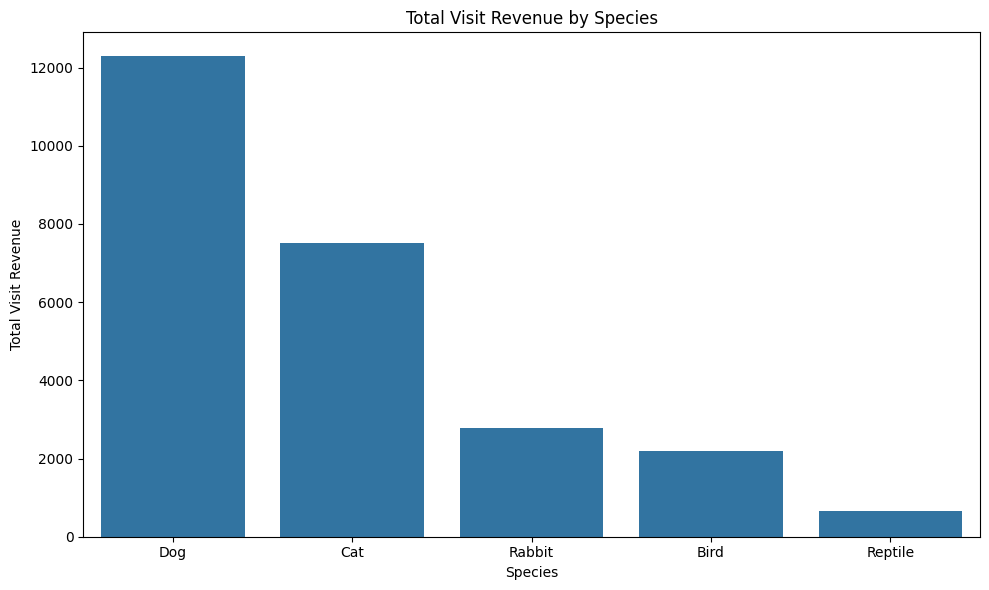

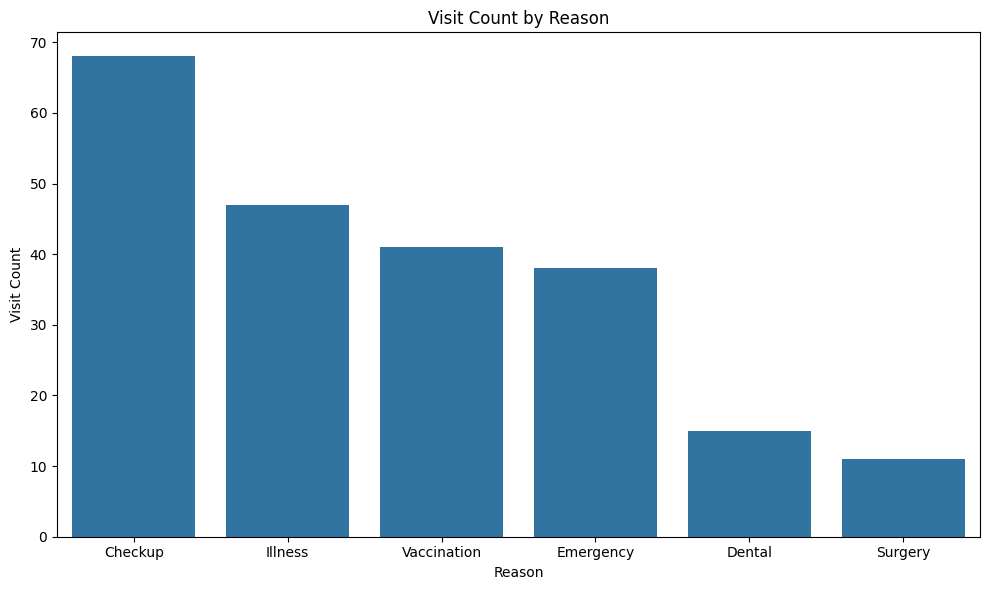

In [38]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: total visit revenue by species (bar)
cost_by_species = pet_visits.groupby('species')['cost'].sum().reset_index().sort_values('cost', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='species', y='cost', data=cost_by_species, ax=ax)
ax.set_title('Total Visit Revenue by Species')
ax.set_xlabel('Species')
ax.set_ylabel('Total Visit Revenue')
plt.tight_layout()
plt.show()

# Chart 2: visit count by reason (bar)
count_by_reason = visits.groupby('reason')['visit_id'].count().reset_index().sort_values('visit_id', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='reason', y='visit_id', data=count_by_reason, ax=ax)
ax.set_title('Visit Count by Reason')
ax.set_xlabel('Reason')
ax.set_ylabel('Visit Count')
plt.tight_layout()

---
# 💼 Business Insights
**What did I discover?**

- Dog visits bring in the most revenue (**$12,288**) and Reptile the least (**$651**).
  (진료매출은 Dog가 가장 많고($12,288) Reptile이 가장 적음($651))
- Mark Miller has the most pets registered (**4**). Several other owners have **3**.
  (등록 반려동물은 Mark Miller가 가장 많고(4마리) 3마리인 보호자가 여러 명)
- Sadie, a cat owned by Anna Johnson, has the most visits (**8**). Checkup is the most common reason (about **68** of 220 visits).
  (방문이 가장 많은 반려동물은 Anna Johnson의 고양이 Sadie(8회). 방문 사유는 Checkup이 가장 많음(220건 중 약 68건))
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Plan supplies and appointment time around dogs and cats, because they account for the two highest revenue bars.
   (개와 고양이 진료에 재료와 예약 시간을 맞추기. 매출 막대 1위와 2위이기 때문)
2. Keep checkup slots as the default capacity, because checkup is the most common visit reason (about **68**).
   (기본 예약 용량은 검진에 맞추기. Checkup이 가장 많은 방문 사유이기 때문(약 68건))
3. Look at owners with 3 or 4 pets, such as Mark Miller, when sending reminders. One household can bring several patients.
   (리마인더를 보낼 때 반려동물이 3~4마리인 보호자(예: Mark Miller)를 보기. 한 가구가 여러 환자를 데려올 수 있음)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- Question 3 first grouped by `owner_id`, so the count was the owner's visits across all their pets. The question asks for one pet, so the group has to be `pet_id`.
  (Question 3을 처음에는 owner_id로 묶어서, 그 보호자의 모든 반려동물 방문이 합쳐짐. 질문은 반려동물 한 마리이므로 pet_id로 묶어야 함)
- Chart 1's y-axis says "Total Visit Revenue" without the unit. It should say USD.
  (차트 1의 y축에 단위가 없음. USD라고 써야 함)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- `merge` on `pet_id` or `owner_id` attaches the other table's columns to each matching row.
  (pet_id나 owner_id로 merge하면 맞는 행에 다른 테이블의 컬럼이 붙음)
- The groupby column decides what "one" means. `owner_id` counts a household, and `pet_id` counts one animal.
  (groupby에 넣는 컬럼이 '한 건'의 기준. owner_id는 가구이고 pet_id는 반려동물 한 마리)
- After a merge, one pet can appear on many rows, once per visit. The count of those rows is the visit count.
  (merge 뒤에는 반려동물 한 마리가 진료 한 건마다 한 행으로 나옴. 그 행 수가 방문 횟수)
  

---
# 🧠 Reflection

**What was difficult?**
Question 3: finding the pet with the most visits, not the owner.
(Question 3에서 보호자가 아니라 방문이 가장 많은 반려동물을 찾는 것)

**Why?**
The merged table has one row per visit, so grouping by the owner adds every pet in that household together.
(합친 표는 진료 한 건이 한 행이라, 보호자로 묶으면 그 집의 반려동물이 모두 합쳐짐)

**How did I solve it?**
Grouped by `pet_id`, then filtered the merged table to that pet to read the owner name.
(pet_id로 묶은 다음, 그 반려동물만 남겨 보호자 이름을 읽음)

**What would I do differently next time?**
Name the groupby column from the question before writing the merge. One pet, one owner, or one species.
(merge를 쓰기 전에 질문이 한 마리인지, 한 보호자인지, 한 종인지 그룹 기준을 먼저 정하기)



---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★★☆☆☆  
Merging on a key is clear. Choosing `pet_id` versus `owner_id` for the count needed a correction.  
(키로 merge하는 것은 이해. 건수를 셀 때 pet_id와 owner_id 중 무엇을 쓸지는 수정이 필요했음)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★★★☆☆☆☆  
Question 3's grouping level was the hardest.  
(Question 3의 집계 단위가 제일 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 22 — SQL intermediate, JOIN and CASE WHEN (Round 2/5)
  (SQL 중급, JOIN과 CASE WHEN 복습)
  